In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, 
    BatchNormalization, Activation, GlobalAveragePooling2D
)
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.21.0
Keras version: 3.13.2


In [2]:
import zipfile

with zipfile.ZipFile("FruitinAmazon.zip", 'r') as zip_ref:
    zip_ref.extractall(".")

print("Dataset folder extracted successfully!")

Dataset folder extracted successfully!


In [5]:

train_dir = "FruitinAmazon/train"  

class_names = sorted(os.listdir(train_dir))

if not class_names:
    print("No class directories found in the train folder!")
else:
    print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [7]:
corrupted_images = []  
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):  
        images = os.listdir(class_path)
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()  
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

# Print results
if corrupted_images:
    print("\nCorrupted Images Found:")
    for img in corrupted_images:
        print(img)
    print(f"\nTotal corrupted images: {len(corrupted_images)}")
else:
    print("\nNo corrupted images found.")


No corrupted images found.


In [9]:

class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path) 
                 if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images)  

print("\nClass Distribution:")
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print(f"{'Total Images:':<25}{sum(class_counts.values()):>15}")


Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15
Total Images:                         90


In [ ]:

selected_images = []  
selected_labels = []  

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path) 
                 if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:  # Ensure the class folder is not empty
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

num_classes = len(selected_images)
cols = (num_classes + 1) // 2  
rows = 2  

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off")  

plt.tight_layout()
plt.show()

In [11]:

image_size = (224, 224)  
batch_size = 32

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"\nNumber of classes: {num_classes}")
print(f"Class names: {class_names}")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.

Number of classes: 6
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [13]:

for images, labels in train_ds.take(1): 
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print(f"\nThis means:")
    print(f"  - Batch size: {images.shape[0]} images")
    print(f"  - Image dimensions: {images.shape[1]}x{images.shape[2]} pixels")
    print(f"  - Color channels: {images.shape[3]} (RGB)")

Images shape: (32, 224, 224, 3)
Labels shape: (32,)

This means:
  - Batch size: 32 images
  - Image dimensions: 224x224 pixels
  - Color channels: 3 (RGB)


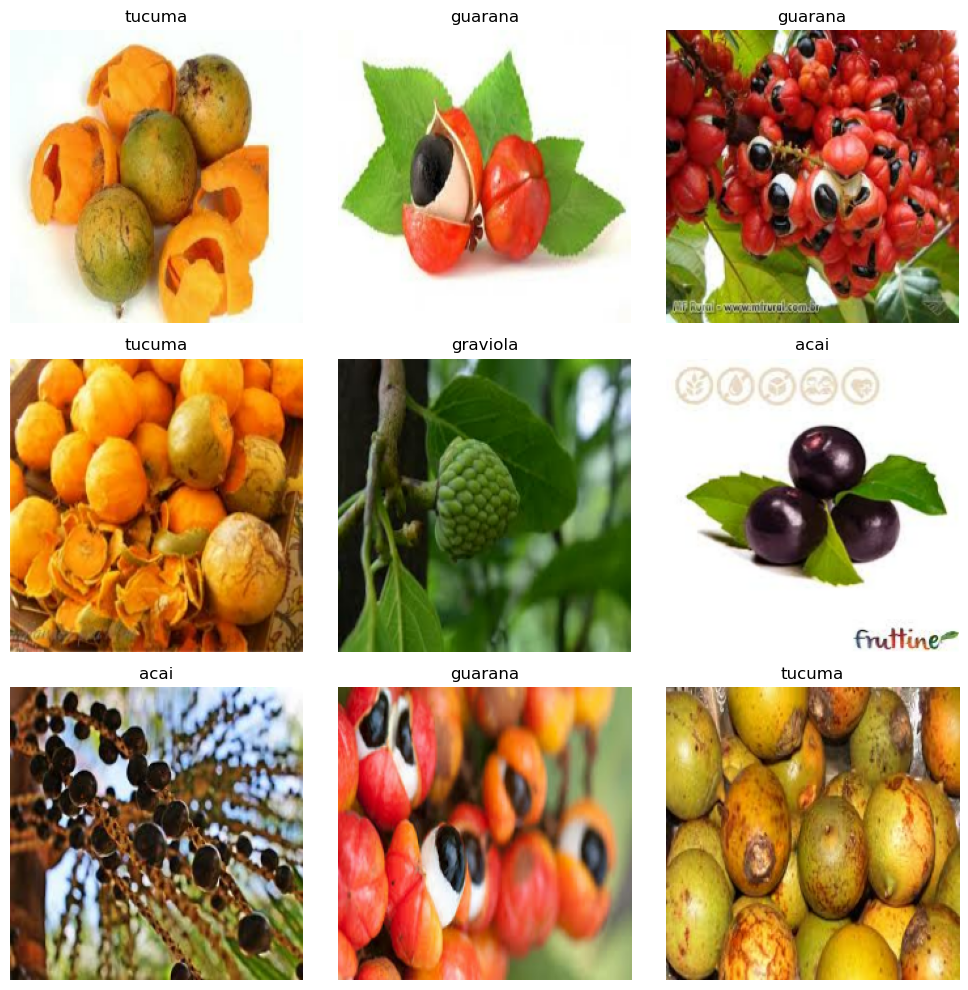

In [65]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):  
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
plt.tight_layout()
plt.show()

In [67]:
# Define data augmentation layers
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
]

def data_augmentation(images):
    """Apply data augmentation to a batch of images"""
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

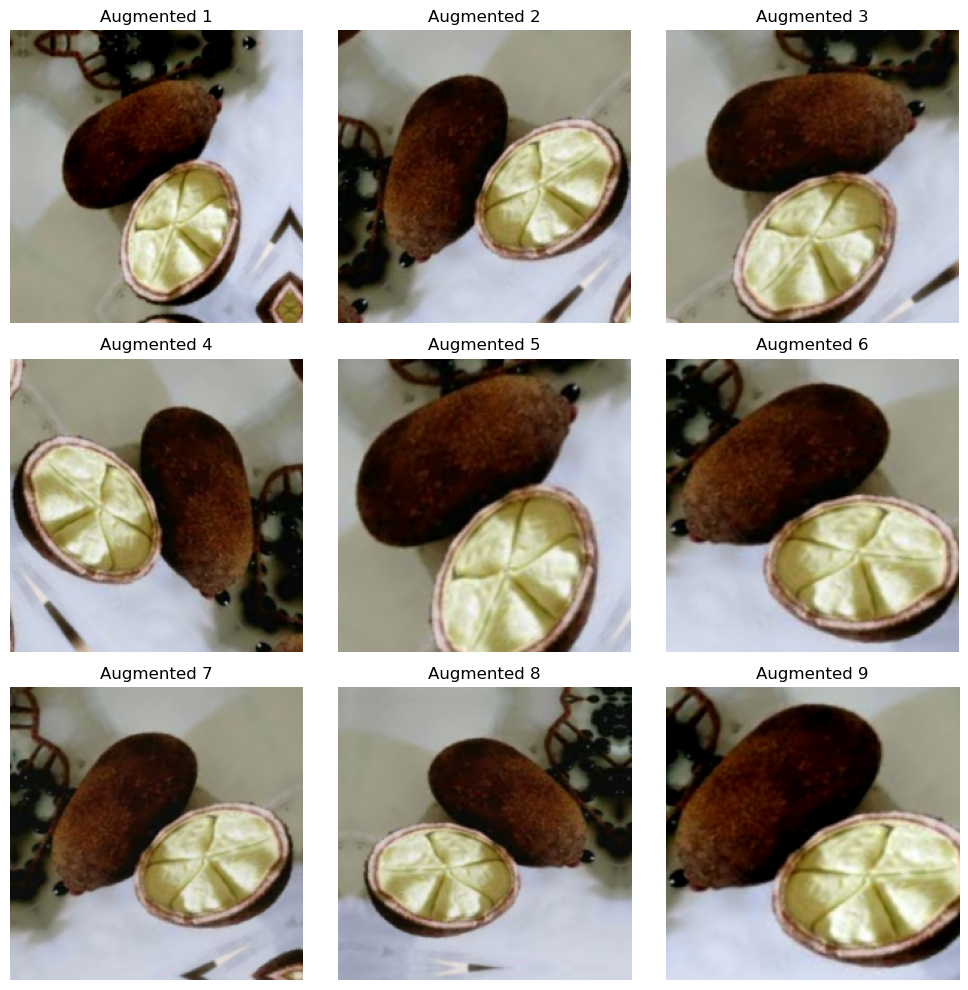

In [69]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented_images[0]).astype("uint8"))
        plt.title(f"Augmented {i+1}")
        plt.axis("off")
plt.tight_layout()
plt.show()

In [71]:

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [73]:

model_scratch = Sequential([
    layers.Lambda(data_augmentation, input_shape=(224, 224, 3)),
    
    layers.Rescaling(1./255),
    
    # First Convolutional Block
    Conv2D(32, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    # Second Convolutional Block
    Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    # Third Convolutional Block
    Conv2D(128, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    # Fourth Convolutional Block
    Conv2D(256, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    # Flatten the output
    Flatten(),
    
    # First Fully Connected Layer
    Dense(512, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),
    
    # Second Fully Connected Layer
    Dense(256, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),
    
    # Third Fully Connected Layer
    Dense(128, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),
    
    # Output Layer
    Dense(num_classes, activation='softmax')
])

# Compile the model
model_scratch.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
model_scratch.summary()

C:\Users\samye\anaconda3\Lib\site-packages\keras\src\layers\core\lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             

 Total params: 26,249,542 (100.13 MB)

 Trainable params: 26,246,790 (100.12 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [75]:

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7
)

epochs = 50  

history_scratch = model_scratch.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.2083 - loss: 2.2543 - val_accuracy: 0.0556 - val_loss: 1.8619 - learning_rate: 0.0010
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.2639 - loss: 2.1074 - val_accuracy: 0.1111 - val_loss: 1.8770 - learning_rate: 0.0010
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.2361 - loss: 2.0757 - val_accuracy: 0.2222 - val_loss: 1.8028 - learning_rate: 0.0010
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.2361 - loss: 2.1120 - val_accuracy: 0.2222 - val_loss: 1.7231 - learning_rate: 0.0010
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.2778 - loss: 1.8262 - val_accuracy: 0.2222 - val_loss: 1.7158 - learning_rate: 0.0010
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.2639 - loss: 1.8044 - val_accuracy: 0.2222 - val_loss: 1.8130 - learning_rate: 0.0010
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.2778 - loss: 1.8730 - val_accuracy: 0.2222 - val_loss: 1

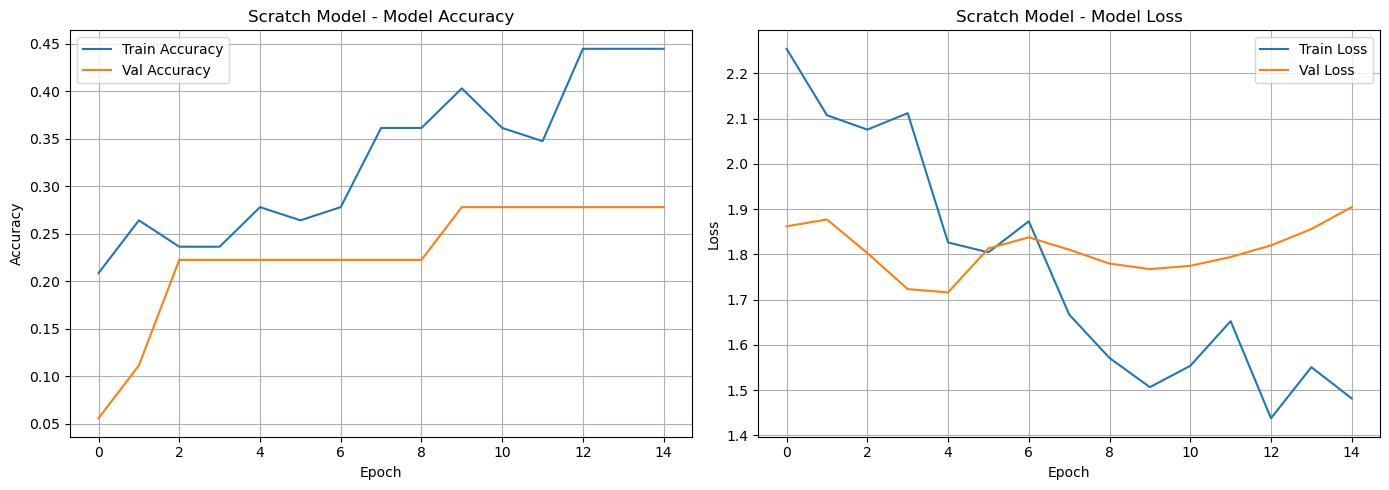

In [76]:
def plot_training_history(history, title_prefix=""):
    """Plot training and validation accuracy and loss"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot accuracy
    ax1.plot(history.history['accuracy'], label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
    ax1.set_title(f'{title_prefix}Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)
    
    # Plot loss
    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Val Loss')
    ax2.set_title(f'{title_prefix}Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history_scratch, "Scratch Model - ")

In [77]:

loss_scratch, accuracy_scratch = model_scratch.evaluate(val_ds)
print(f"Model from Scratch - Validation Results:")
print(f"Validation Loss: {loss_scratch:.4f}")
print(f"Validation Accuracy: {accuracy_scratch:.4f} ({accuracy_scratch*100:.2f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.2222 - loss: 1.7158
Model from Scratch - Validation Results:
Validation Loss: 1.7158
Validation Accuracy: 0.2222 (22.22%)


In [78]:

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model_scratch.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(labels.numpy())

print("\nClassification Report - Model from Scratch:")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report - Model from Scratch:
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         3
     cupuacu       0.00      0.00      0.00         4
    graviola       0.00      0.00      0.00         1
     guarana       0.00      0.00      0.00         1
     pupunha       0.27      1.00      0.42         4
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.22        18
   macro avg       0.04      0.17      0.07        18
weighted avg       0.06      0.22      0.09        18



C:\Users\samye\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\samye\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\samye\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


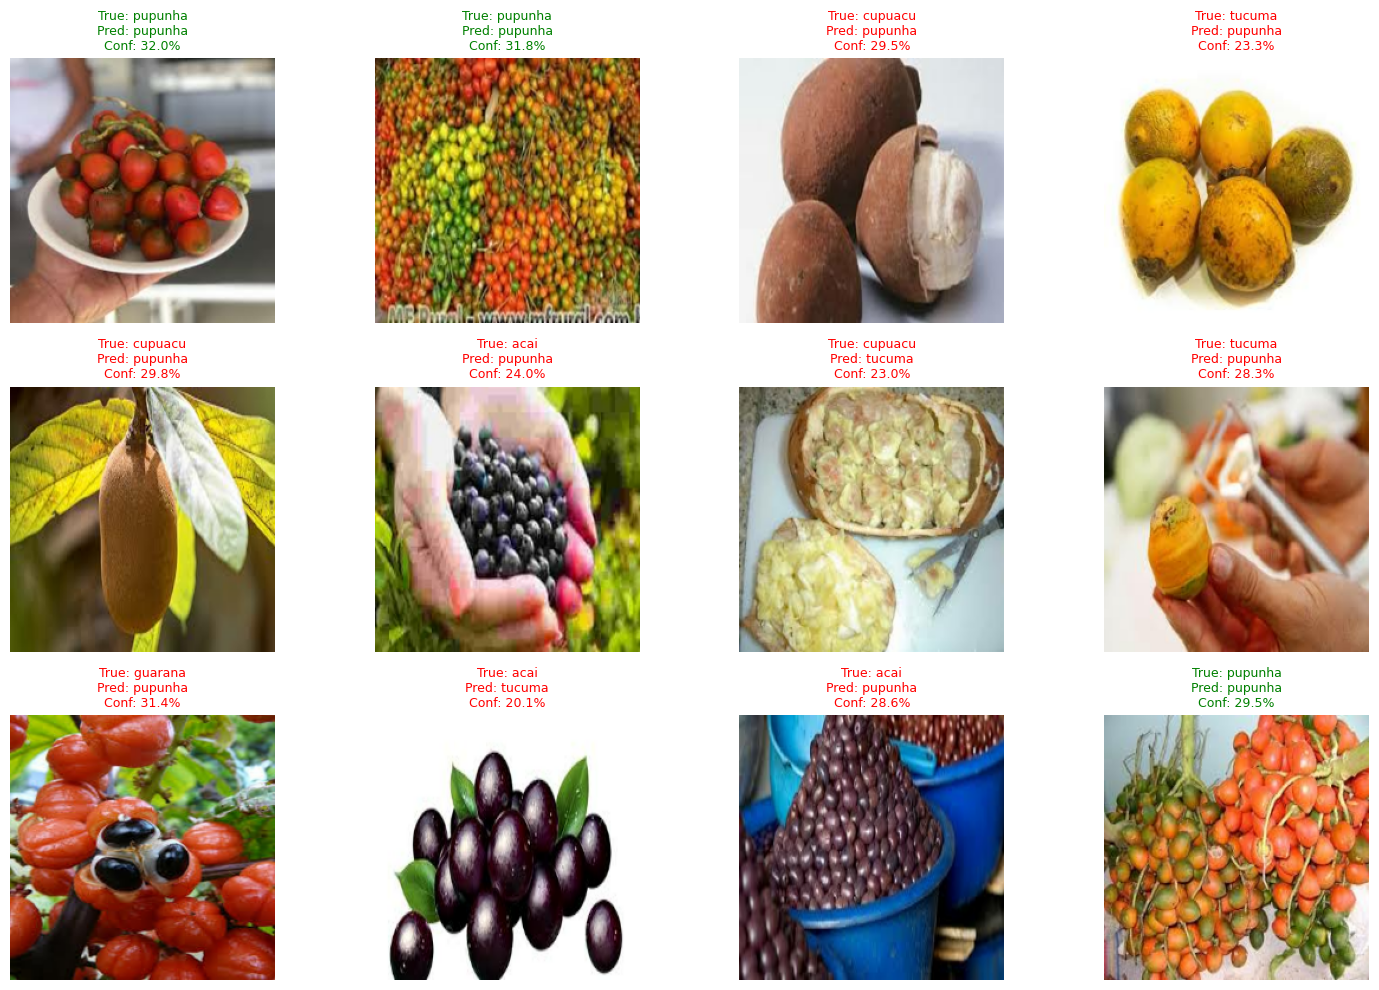

In [79]:

plt.figure(figsize=(15, 10))
for images, labels in val_ds.take(1):
    predictions = model_scratch.predict(images, verbose=0)
    for i in range(min(12, len(images))):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        pred_label = class_names[np.argmax(predictions[i])]
        true_label = class_names[int(labels[i])]
        confidence = np.max(predictions[i]) * 100
        
        color = 'green' if pred_label == true_label else 'red'
        plt.title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%", 
                 color=color, fontsize=9)
        plt.axis("off")
plt.tight_layout()
plt.show()

In [80]:

base_model = VGG16(
    weights='imagenet', 
    include_top=False, 
    input_shape=(224, 224, 3)
)

print("VGG16 Base Model Summary:")
print(f"Total layers: {len(base_model.layers)}")
print(f"Total parameters: {base_model.count_params():,}")

VGG16 Base Model Summary:
Total layers: 19
Total parameters: 14,714,688


In [81]:

for layer in base_model.layers:
    layer.trainable = False

trainable_count = sum([1 for layer in base_model.layers if layer.trainable])
non_trainable_count = sum([1 for layer in base_model.layers if not layer.trainable])

print(f"\nTrainable layers: {trainable_count}")
print(f"Non-trainable layers: {non_trainable_count}")


Trainable layers: 0
Non-trainable layers: 19


In [82]:

inputs = keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = layers.Rescaling(1./255)(x)

x = base_model(x, training=False)

x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation=None)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)

x = Dense(512, activation=None)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)

outputs = Dense(num_classes, activation='softmax')(x)

model_transfer = Model(inputs=inputs, outputs=outputs)

model_transfer.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_2 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_2 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_2               │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,774,022 (60.17 MB)

 Trainable params: 1,056,262 (4.03 MB)

 Non-trainable params: 14,717,760 (56.14 MB)

In [83]:

model_transfer.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [84]:

early_stopping_transfer = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr_transfer = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7
)

epochs_transfer = 30

history_transfer = model_transfer.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs_transfer,
    callbacks=[early_stopping_transfer, reduce_lr_transfer]
)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - accuracy: 0.1667 - loss: 2.2805 - val_accuracy: 0.0556 - val_loss: 1.8881 - learning_rate: 0.0010
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 5s/step - accuracy: 0.5417 - loss: 1.1457 - val_accuracy: 0.0556 - val_loss: 1.8954 - learning_rate: 0.0010
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step - accuracy: 0.6111 - loss: 0.8928 - val_accuracy: 0.1667 - val_loss: 1.8991 - learning_rate: 0.0010
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 0.6528 - loss: 0.8553 - val_accuracy: 0.1667 - val_loss: 1.9109 - learning_rate: 0.0010
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step - accuracy: 0.7222 - loss: 0.7076 - val_accuracy: 0.1111 - val_loss: 1.9133 - learning_rate: 0.0010
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step - accuracy: 0.7917 - loss: 0.5705 - val_accuracy: 0.1111 - val_loss: 1.9055 - learning_rate: 0.0010
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step - accuracy: 0.8750 - loss: 0.3593 - val_accuracy: 0.1111 - val_l

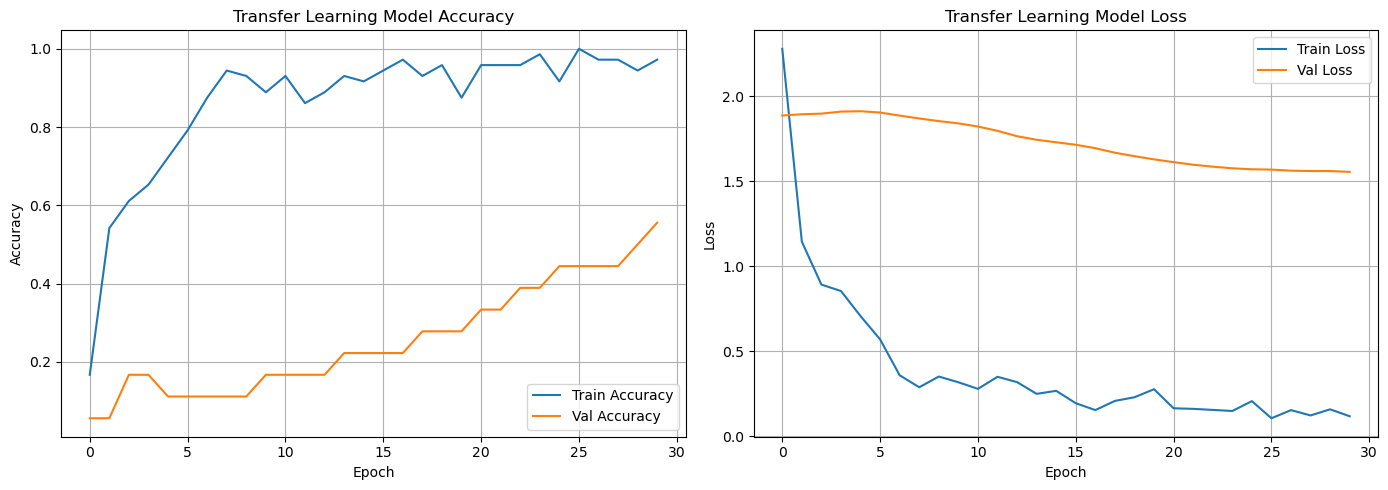

In [85]:
plot_training_history(history_transfer, "Transfer Learning ")

In [86]:

loss_transfer, accuracy_transfer = model_transfer.evaluate(val_ds)
print(f"Transfer Learning Model - Validation Results:")
print(f"Validation Loss: {loss_transfer:.4f}")
print(f"Validation Accuracy: {accuracy_transfer:.4f} ({accuracy_transfer*100:.2f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5556 - loss: 1.5563
Transfer Learning Model - Validation Results:
Validation Loss: 1.5563
Validation Accuracy: 0.5556 (55.56%)


In [87]:

y_true_transfer = []
y_pred_transfer = []

for images, labels in val_ds:
    predictions = model_transfer.predict(images, verbose=0)
    y_pred_transfer.extend(np.argmax(predictions, axis=1))
    y_true_transfer.extend(labels.numpy())


print("\nClassification Report - Transfer Learning Model:")
print(classification_report(y_true_transfer, y_pred_transfer, target_names=class_names))


Classification Report - Transfer Learning Model:
              precision    recall  f1-score   support

        acai       0.50      0.33      0.40         3
     cupuacu       0.80      1.00      0.89         4
    graviola       0.17      1.00      0.29         1
     guarana       1.00      1.00      1.00         1
     pupunha       0.67      0.50      0.57         4
      tucuma       1.00      0.20      0.33         5

    accuracy                           0.56        18
   macro avg       0.69      0.67      0.58        18
weighted avg       0.75      0.56      0.56        18



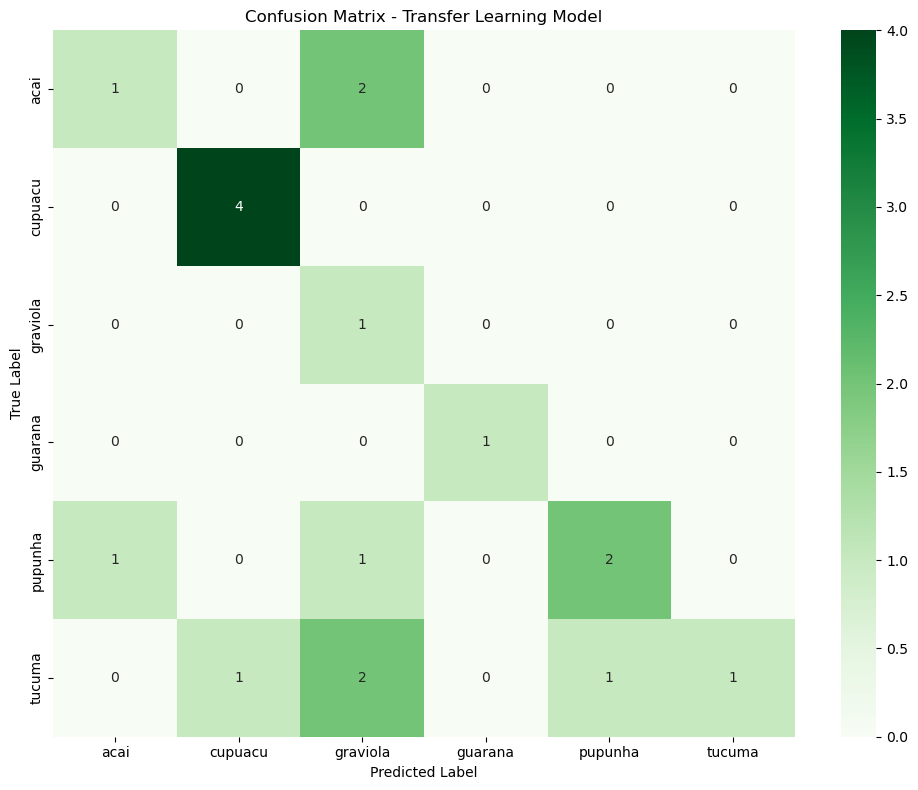

In [88]:

cm_transfer = confusion_matrix(y_true_transfer, y_pred_transfer)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_transfer, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Transfer Learning Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

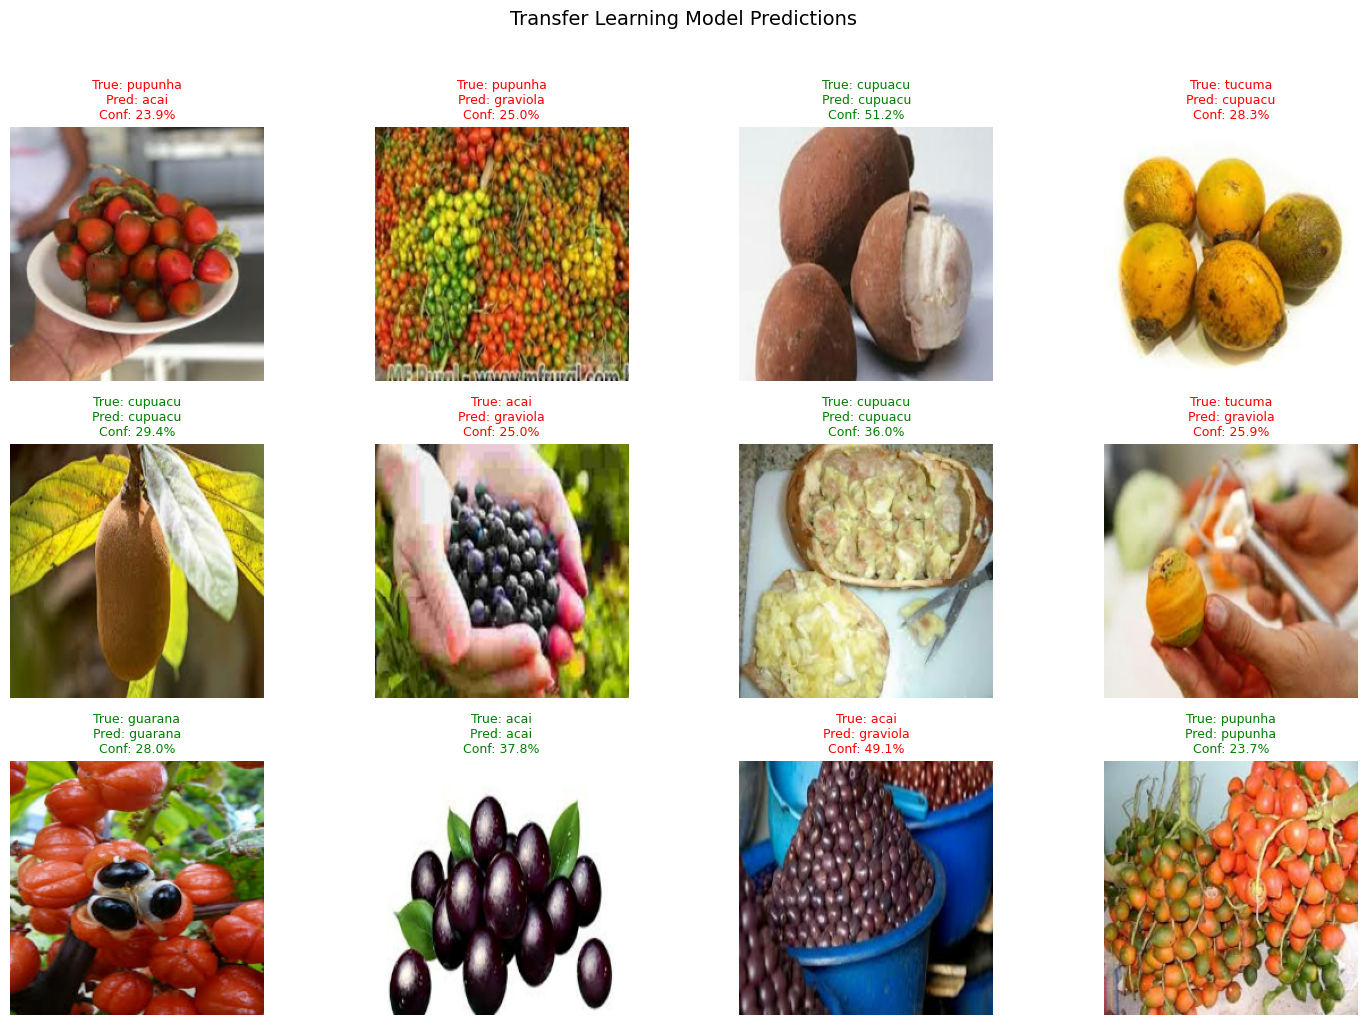

In [89]:

plt.figure(figsize=(15, 10))
for images, labels in val_ds.take(1):
    predictions = model_transfer.predict(images, verbose=0)
    for i in range(min(12, len(images))):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        pred_label = class_names[np.argmax(predictions[i])]
        true_label = class_names[int(labels[i])]
        confidence = np.max(predictions[i]) * 100
        
        color = 'green' if pred_label == true_label else 'red'
        plt.title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%", 
                 color=color, fontsize=9)
        plt.axis("off")
plt.suptitle('Transfer Learning Model Predictions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [91]:

comparison_data = {
    'Metric': ['Validation Loss', 'Validation Accuracy', 'Training Time (epochs)'],
    'Model from Scratch': [
        f"{loss_scratch:.4f}",
        f"{accuracy_scratch:.4f} ({accuracy_scratch*100:.2f}%)",
        f"{len(history_scratch.history['loss'])}"
    ],
    'Transfer Learning': [
        f"{loss_transfer:.4f}",
        f"{accuracy_transfer:.4f} ({accuracy_transfer*100:.2f}%)",
        f"{len(history_transfer.history['loss'])}"
    ]
}

import pandas as pd
df_comparison = pd.DataFrame(comparison_data)

print("MODEL COMPARISON SUMMARY")
print(df_comparison.to_string(index=False))

if accuracy_transfer > accuracy_scratch:
    improvement = ((accuracy_transfer - accuracy_scratch) / accuracy_scratch) * 100
    print(f"\nTransfer Learning model performed BETTER!")
    print(f"  Improvement: {improvement:.2f}% increase in accuracy")
else:
    difference = ((accuracy_scratch - accuracy_transfer) / accuracy_scratch) * 100
    print(f"\nModel from Scratch performed better!")
    print(f"  Difference: {difference:.2f}%")


MODEL COMPARISON SUMMARY
                Metric Model from Scratch Transfer Learning
       Validation Loss             1.7158            1.5563
   Validation Accuracy    0.2222 (22.22%)   0.5556 (55.56%)
Training Time (epochs)                 15                30

Transfer Learning model performed BETTER!
  Improvement: 150.00% increase in accuracy


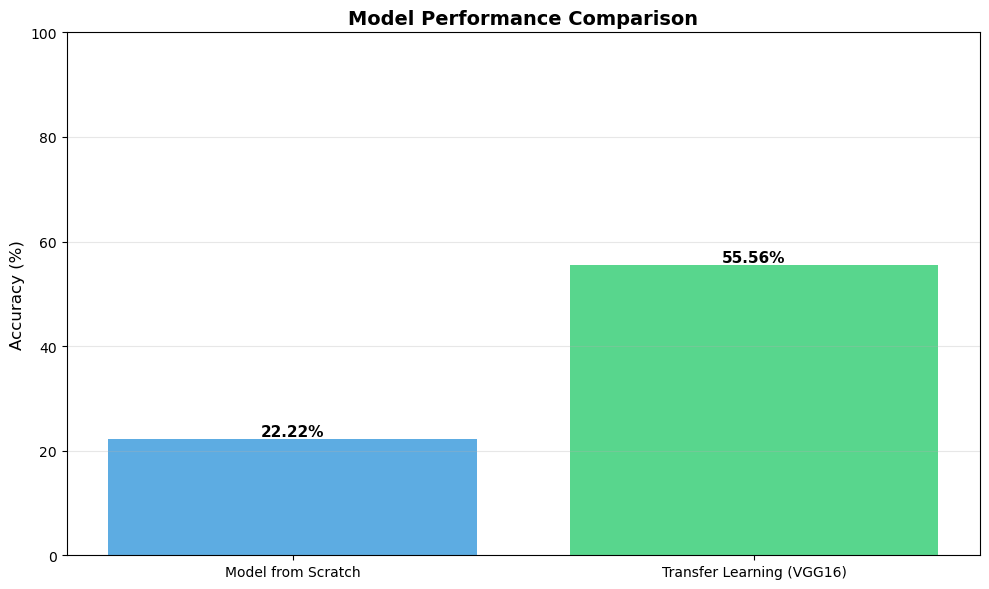

In [92]:

models = ['Model from Scratch', 'Transfer Learning (VGG16)']
accuracies = [accuracy_scratch * 100, accuracy_transfer * 100]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=['#3498db', '#2ecc71'], alpha=0.8)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.ylim([0, 100])
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [93]:
# Save models
model_scratch.save('model_from_scratch.h5')
model_transfer.save('model_transfer_learning.h5')
